Importy

In [5]:
import seaborn as sns
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import cluster, datasets, metrics
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn import metrics
from sklearn.decomposition import PCA

In [6]:
from scipy.io import arff
source = arff.loadarff('Dry_Bean_Dataset.arff')
df = pd.DataFrame(source[0])

Analiza Danych

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  float64
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  float64
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(16), object(

Mamy 16 cech i 1 etykietę

In [8]:
print(df.isnull().sum().sort_values(ascending=False).head(10))

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
dtype: int64


Nie mamy żadnych brakujących wartości

Macierz Korelacji

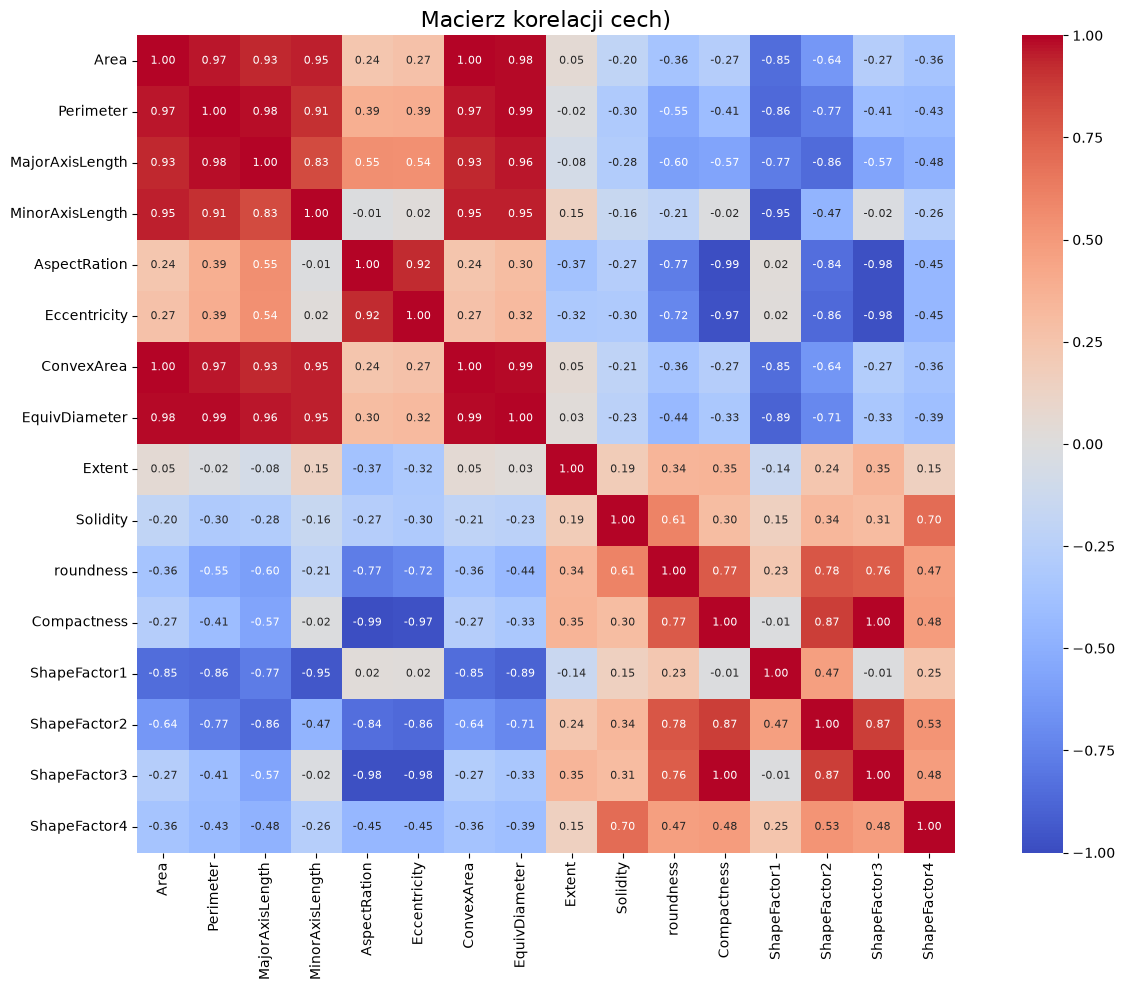

In [9]:
X_features = df.drop(columns=['Class']) 

corr_matrix = X_features.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, 
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1, vmax=1,
            square=True,
            annot_kws={"size": 8})

plt.title("Macierz korelacji cech)", fontsize=16)
plt.tight_layout()
plt.show()

Widzimy na podstawie tego, że moglibyśmy oddzielić cały jeden gatunek fasol na podstawie tylko tych dwóch cech. 

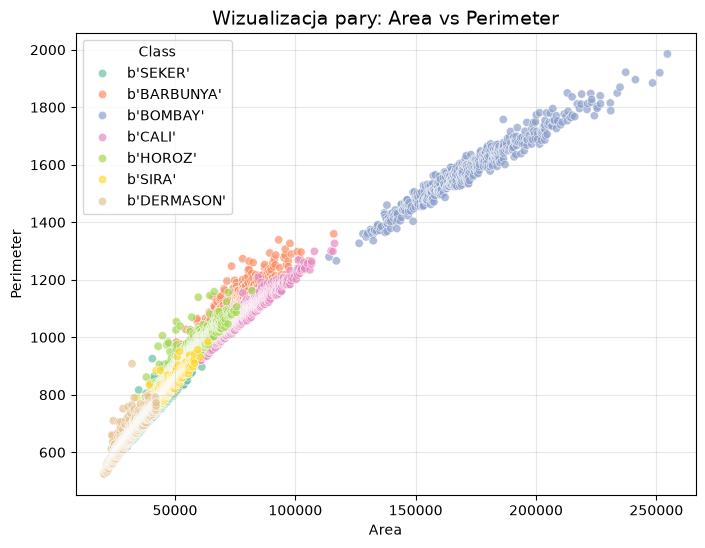

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Area', y='Perimeter', hue='Class', palette='Set2', alpha=0.7)
plt.title("Wizualizacja pary: Area vs Perimeter", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

Widać, że nasz zbiór jest pełen bardzo mocno skorelowanych cech. Stąd można przepuszczać, że zawiera spójne grupy danych - potencjalny cel naszej klasteryzacji

Standaryzacja - Potrzebna żeby uniknąć problemu z tutoriala

In [10]:
scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X_features)

X_scaled = pd.DataFrame(X_scaled_array, columns=X_features.columns)

2.1. K-Means

Inercja dla k=4: 85834.36


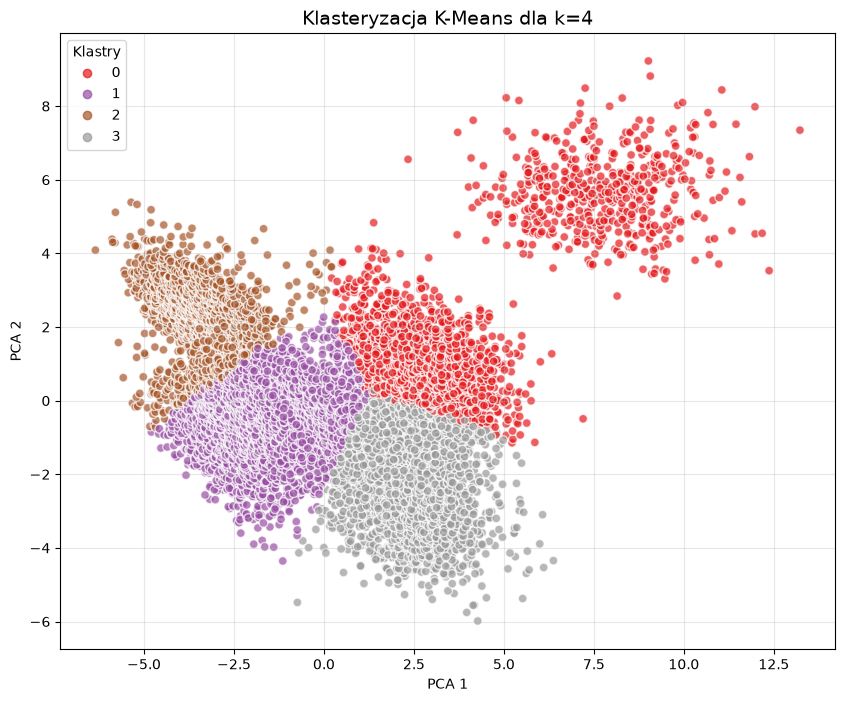

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

kmeans.fit(X_scaled)
assigned_clusters = kmeans.labels_

print(f"Inercja dla k={4}: {kmeans.inertia_:.2f}")

def visualize_clusters_2d(data, predictions, title="Wizualizacja klastrów"):
    pca = PCA(n_components=2)
    data_pca = pca.fit_transform(data)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(data_pca[:, 0], data_pca[:, 1], 
                          c=predictions, cmap='Set1', 
                          alpha=0.7, edgecolors='w', s=40)
    
    plt.title(title, fontsize=14)
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    
    plt.legend(*scatter.legend_elements(), title="Klastry")
    plt.grid(True, alpha=0.3)
    plt.show()

visualize_clusters_2d(X_scaled, assigned_clusters, title=f"Klasteryzacja K-Means dla k={4}")

2.2. Badanie wpływu parametru k

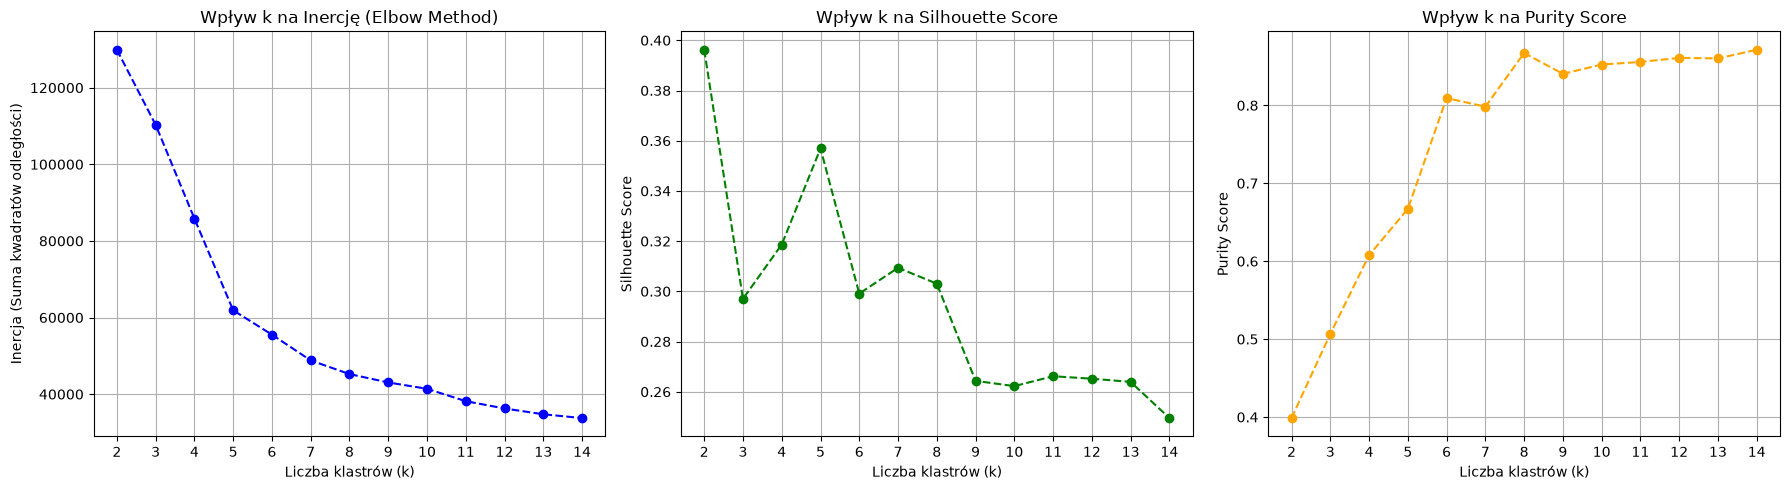

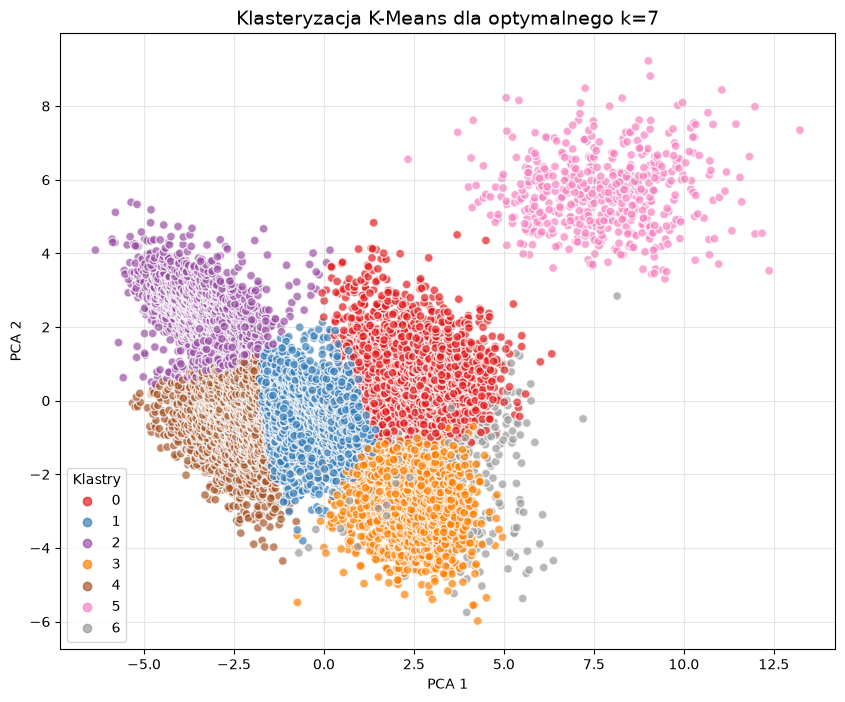

In [12]:

inertias = []
silhouette_scores = []
purity_scores = []

k_range = range(2, 15)
true_labels = df['Class']

def purity_score(labels_true: np.ndarray, labels_pred: np.ndarray) -> float:
    cont_matrix = metrics.cluster.contingency_matrix(labels_true, labels_pred)
    max_per_cluster = np.max(cont_matrix, axis=0)
    return np.sum(max_per_cluster) / np.sum(cont_matrix)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    assigned_clusters = kmeans.labels_

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, assigned_clusters))
    purity_scores.append(purity_score(true_labels, assigned_clusters))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_range, inertias, marker='o', linestyle='--', color='blue')
axes[0].set_title('Wpływ k na Inercję (Elbow Method)')
axes[0].set_xlabel('Liczba klastrów (k)')
axes[0].set_ylabel('Inercja (Suma kwadratów odległości)')
axes[0].set_xticks(k_range)
axes[0].grid(True)

axes[1].plot(k_range, silhouette_scores, marker='o', linestyle='--', color='green')
axes[1].set_title('Wpływ k na Silhouette Score')
axes[1].set_xlabel('Liczba klastrów (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_range)
axes[1].grid(True)

axes[2].plot(k_range, purity_scores, marker='o', linestyle='--', color='orange')
axes[2].set_title('Wpływ k na Purity Score')
axes[2].set_xlabel('Liczba klastrów (k)')
axes[2].set_ylabel('Purity Score')
axes[2].set_xticks(k_range)
axes[2].grid(True)

plt.tight_layout()
plt.show()

optimal_k = 7
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_optimal.fit(X_scaled)
optimal_clusters = kmeans_optimal.labels_

visualize_clusters_2d(X_scaled, optimal_clusters, title=f"Klasteryzacja K-Means dla optymalnego k={optimal_k}")

Widać, że k przestaje gwałtownie spadać gdzieś w okolicach 6 i 7 (7 to też liczba gatunków fasoli w naszym zbiorze).

Silhouette > 0, a więc jest to model, który w miarę dobrze oddziela klastry od siebie.

Purity = 0.8 dla optymalnego k=7, to też bardzo dobry wynik, oznacza to, że 8/10 nasion jest dobrze przypisane do danego gatunku.

3. Klasteryzacja Aglomeracyjna

3.1. Wizualizacje i badanie wlywu parametru k na metryki

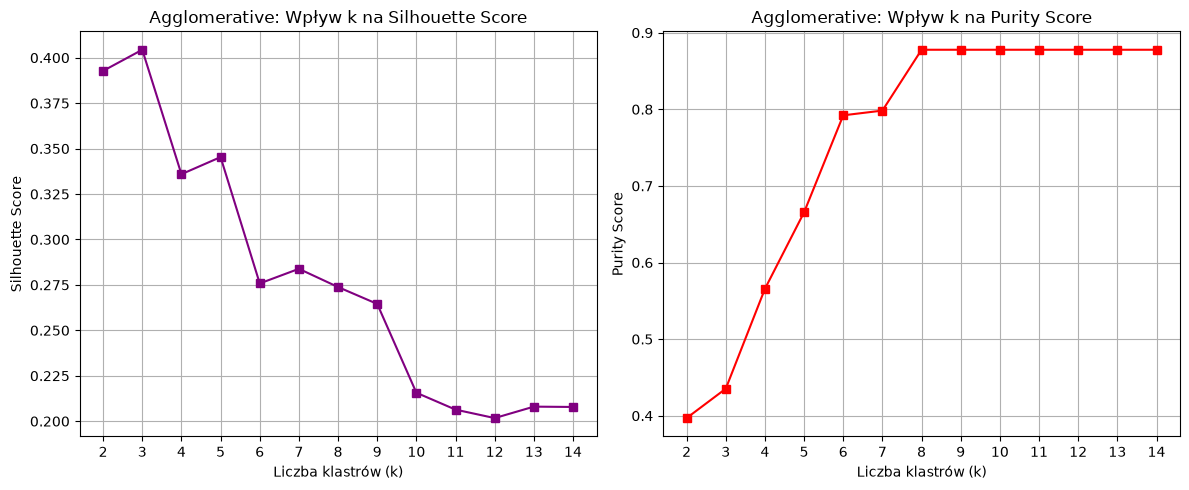

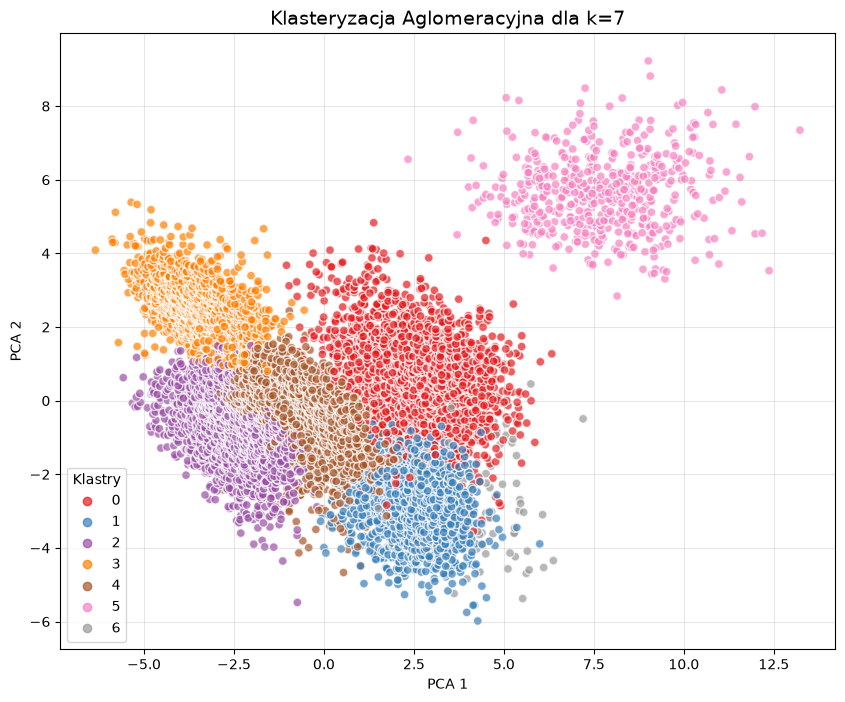

In [13]:
agg_silhouette_scores = []
agg_purity_scores = []

for k in k_range:
    agg_model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    
    assigned_clusters_agg = agg_model.fit_predict(X_scaled)
    
    agg_silhouette_scores.append(silhouette_score(X_scaled, assigned_clusters_agg))
    agg_purity_scores.append(purity_score(true_labels, assigned_clusters_agg))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(k_range, agg_silhouette_scores, marker='s', linestyle='-', color='purple')
axes[0].set_title('Agglomerative: Wpływ k na Silhouette Score')
axes[0].set_xlabel('Liczba klastrów (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticks(k_range)
axes[0].grid(True)

axes[1].plot(k_range, agg_purity_scores, marker='s', linestyle='-', color='red')
axes[1].set_title('Agglomerative: Wpływ k na Purity Score')
axes[1].set_xlabel('Liczba klastrów (k)')
axes[1].set_ylabel('Purity Score')
axes[1].set_xticks(k_range)
axes[1].grid(True)

plt.tight_layout()
plt.show()

agg_optimal = AgglomerativeClustering(n_clusters=optimal_k)
optimal_clusters_agg = agg_optimal.fit_predict(X_scaled)

visualize_clusters_2d(X_scaled, optimal_clusters_agg, title=f"Klasteryzacja Aglomeracyjna dla k={optimal_k}")

Widać, że wyniki (w metrykach silhouette, purity score) klasteryzacji aglomeracyjnej sa zbliżone do wyników k-Means.

3.2. Pomiar czasu działania algorytmów

In [16]:
# Pomiar dla K-Means, k=7
start_km = time.perf_counter()
kmeans_test = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_test.fit(X_scaled)
time_km = time.perf_counter() - start_km

# 2. Pomiar dla Agglomerative, k=7
start_agg = time.perf_counter()
agg_test = AgglomerativeClustering(n_clusters=optimal_k)
agg_test.fit(X_scaled)
time_agg = time.perf_counter() - start_agg

print(f"Czas wykonania K-Means: {time_km:.4f} s")
print(f"Czas wykonania Aglomeracyjnego: {time_agg:.4f} s")

if time_agg > time_km:
    print(f"\nAlgorytm K-Means był szybszy")
else:
    print(f"\nAlgorytm Aglomeracyjny był szybszy")

Czas wykonania K-Means: 0.1651 s
Czas wykonania Aglomeracyjnego: 3.9993 s

Algorytm K-Means był szybszy


Wynika to z tego, że algorytm aglomeracyjny na starcie musi on zapisać w pamięci odległości między każdą para ziaren. 

k-Means natomiast liczy tylko odległości od centroidów. 